In [35]:
using Pkg
Pkg.add("Random")
Pkg.add("JuMP")
Pkg.add("Gurobi")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Plots")

using JuMP, Gurobi, CSV, DataFrames

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


### First model: λ = 0 and α = 0

#### Objective: minimize ∑_{t,i,a} g_i * w_{i,t,a}
#### Dynamics:
####   w[i,t+1,a+1] = w[i,t,a] - x[i,t,a]
####   w[i,t,1]     = N[i,t]  (new arrivals at a=0)

#### Capacity per time t is fixed input Cap[t]

In [44]:
waiting_df = CSV.read("ED_treatment_time.csv", DataFrame)
arrivals_df = CSV.read("ED_arrivals_2.csv", DataFrame)

waiting_df

Row,group,code,name,typical_treatment_time
,String7,Int64,String,Float64
1,Disease,1,"Symptoms, signs, and abnormal clinical and laboratory findings",4.5
2,Disease,2,Injury and poisoning,5.0
3,Disease,3,Diseases of the respiratory system,8.0
4,Disease,4,Diseases of the musculoskeletal system and connective tissue,3.0
5,Disease,5,Diseases of the digestive system,1.0
6,Disease,6,Diseases of the genitourinary system,3.0
7,Disease,7,"Mental, behavioral, and neurodevelopmental disorders",10.0
8,Disease,8,Diseases of the circulatory system,6.0
9,Disease,9,Certain infectious and parasitic diseases,4.0


In [108]:
I = 1:20
T = 24
A = 0:T

# Service time per disease τ_i  we will take from typical_wait_hours
tau = Dict(i => waiting_df.typical_treatment_time[i] for i in I)

# Cost per waiting patient g_i  kept at 1 for the first model
g = Dict(i => 1.0 for i in I)

# Fixed capacity per period (e.g., physician-hours per hour)
# Cap[t] = nb_physician * physician_efficacity
Cap = Dict(t => 1000 for t in 1:T)

# Build N as a Dict[(i,t)] from the file
N = Dict((Int(row.disease_index), Int(row.t)) => Int(row.arrivals) for row in eachrow(arrivals_df))

# N[(3, 12)] = arrivals for disease 3 at hour 12

Dict{Tuple{Int64, Int64}, Int64} with 480 entries:
  (11, 17) => 72
  (16, 14) => 72
  (18, 16) => 72
  (17, 12) => 60
  (8, 15)  => 42
  (16, 16) => 72
  (19, 14) => 72
  (7, 18)  => 30
  (7, 8)   => 30
  (14, 15) => 84
  (7, 24)  => 18
  (1, 9)   => 30
  (15, 23) => 36
  (19, 16) => 72
  (2, 17)  => 36
  (10, 17) => 36
  (18, 18) => 60
  (18, 8)  => 60
  (15, 12) => 60
  ⋮        => ⋮

In [109]:
model = Model(Gurobi.Optimizer)
# set_optimizer_attribute(model, "OutputFlag", 0)  # optional example

@variable(model, w[i in I, t in 1:T, a in 0:T] >= 0, Int)
@variable(model, x[i in I, t in 1:T, a in 0:T] >= 0, Int)

# x ≤ w
@constraint(model, [i in I, t in 1:T, a in 0:T], x[i,t,a] <= w[i,t,a])

# New arrivals at age 0
@constraint(model, [i in I, t in 1:T], w[i,t,0] == N[(i,t)])

# Optional, no initial backlog older than a = 0 at t = 1
@constraint(model, [i in I, a in 1:T], w[i,1,a] == 0)

# Queue dynamics, avoid out of bounds on t+1 and a+1
@constraint(model, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] == w[i,t,a] - x[i,t,a]
)

# Capacity per period
@constraint(model, [t in 1:T],
    sum(tau[i] * x[i,t,a] for i in I, a in 0:T) <= Cap[t]
)

@objective(model, Min, sum(g[i] * w[i,t,a] for i in I, t in 1:T, a in 0:T))

optimize!(model)


Set parameter Username
Set parameter LicenseID to value 2697101
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.1.0 22A380)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 24024 rows, 24000 columns and 70080 nonzeros
Model fingerprint: 0xbc4ab2d7
Variable types: 0 continuous, 24000 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 1e+03]
Found heuristic solution: objective 136441.00000
Presolve removed 23561 rows and 18490 columns
Presolve time: 0.02s
Presolved: 463 rows, 5510 columns, 11010 nonzeros
Variable types: 0 continuous, 5510 integer (0 binary)
Found heuristic solution: objective 135915.00000

Root relaxation: objective 1.070084e+05, 898 iterations, 0.01 seconds (0.02 work units)

    Nodes    |

In [110]:
println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Quick summaries
treated_per_t = Dict(t => value(sum(x[i,t,a] for i in I, a in 0:T)) for t in 1:T)
waiting_per_t = Dict(t => value(sum(w[i,t,a] for i in I, a in 0:T)) for t in 1:T)

# println("\nTotal treated per hour:")
# for t in 1:T
#     println("t=$(t): ", treated_per_t[t])
# end

println("\nTotal waiting per hour:")
for t in 1:T
    println("t=$(t): ", waiting_per_t[t])
end


Status: OPTIMAL
Objective: 107030.0

Total waiting per hour:
t=1: 360.0
t=2: 421.0
t=3: 661.0
t=4: 492.0
t=5: 422.0
t=6: 553.0
t=7: 793.0
t=8: 1344.0
t=9: 1831.0
t=10: 2678.0
t=11: 3132.0
t=12: 3619.0
t=13: 4646.0
t=14: 5264.0
t=15: 6095.0
t=16: 6730.0
t=17: 7380.0
t=18: 7851.0
t=19: 8159.0
t=20: 8481.0
t=21: 8803.0
t=22: 8946.0
t=23: 9105.0
t=24: 9264.0


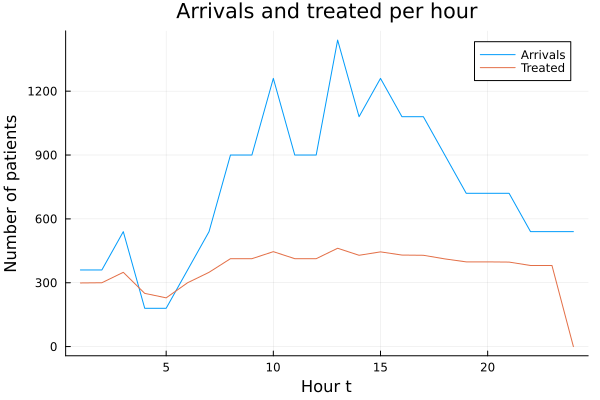

In [125]:
using Plots

# total arrivals per hour (data input)
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# total treated per hour (model output)
treated_per_t  = [sum(value(x[i,t,a]) for i in I, a in 0:T) for t in 1:T]

plot(1:T, arrivals_per_t,
     label = "Arrivals",
     xlabel = "Hour t",
     ylabel = "Number of patients",
     title = "Arrivals and treated per hour")

plot!(1:T, treated_per_t,
      label = "Treated")


Status: OPTIMAL
Objective: 107030.0


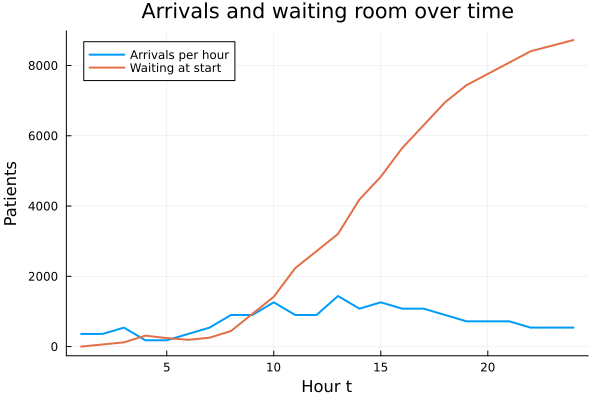

In [123]:
using Plots

# Arrivals per hour from the Dict N
arrivals_per_t = [sum(N[(i,t)] for i in I) for t in 1:T]

# Waiting room count at the start of each hour
waiting_per_t_vec = [value(sum(w[i,t,a] for i in I, a in 1:T)) for t in 1:T]

println("Status: ", termination_status(model))
println("Objective: ", objective_value(model))

# Line plot
plt = plot(1:T, arrivals_per_t,
    label = "Arrivals per hour",
    xlabel = "Hour t",
    ylabel = "Patients",
    title = "Arrivals and waiting room over time",
    legend = :topleft,
    lw = 2,
)
plot!(plt, 1:T, waiting_per_t_vec, label = "Waiting at start", lw = 2)


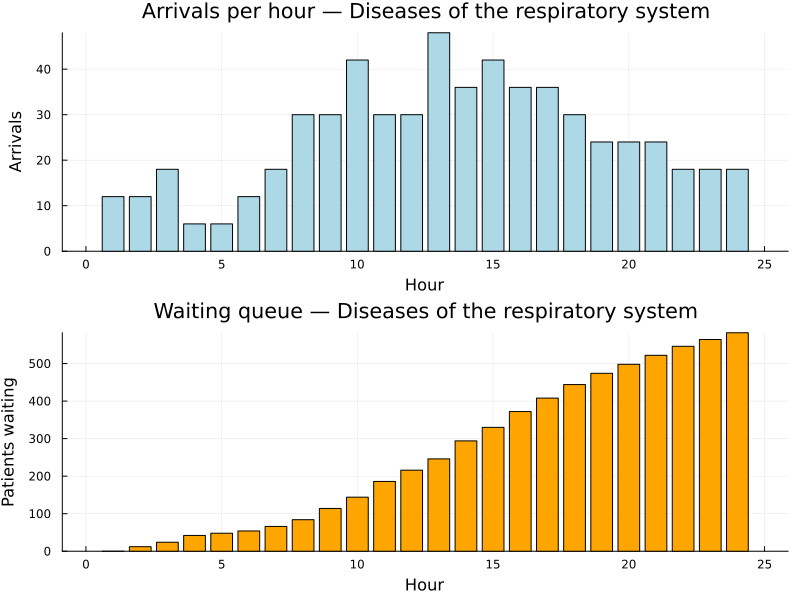

In [126]:
using Plots


function plot_disease_summary(disease_name::String)
    # Look up the disease index from the arrivals DataFrame
    rows = filter(:disease_name => ==(disease_name), arrivals_df)
    if nrow(rows) == 0
        println("Disease not found: ", disease_name)
        return
    end
    i = unique(rows.disease_index)[1]

    # Compute arrivals per hour for this disease
    arrivals_i = [N[(i,t)] for t in 1:T]

    # Compute queue (sum over all ages) from model results
    queue_i = [value(sum(w[i,t,a] for a in 1:T)) for t in 1:T]

    # Plot side by side "boxes" (bar charts)
    plt1 = bar(1:T, arrivals_i,
        xlabel = "Hour",
        ylabel = "Arrivals",
        title = "Arrivals per hour — $(disease_name)",
        legend = false,
        color = :lightblue,
    )

    plt2 = bar(1:T, queue_i,
        xlabel = "Hour",
        ylabel = "Patients waiting",
        title = "Waiting queue — $(disease_name)",
        legend = false,
        color = :orange,
    )

    # Combine vertically
    plot(plt1, plt2, layout = (2,1), size = (800,600))
end

plot_disease_summary("Diseases of the respiratory system")

# Diseases of the respiratory system


### Second model: λ is not 0 and α = 0

#### Objective: minimize ∑_{t,i,a} g_i * w_{i,t,a} + λ* ∑_{i,t} z_{i,t}
#### Dynamics:
####   w[i,t+1,a+1] = w[i,t,a] - x[i,t,a]
####   w[i,t,1]     = N[i,t]  (new arrivals at a=0)

#### Capacity per time t is fixed input Cap[t]

In [107]:
using CSV, DataFrames
using JuMP, Gurobi



# Physician capacity parameters
C_phys   = 4.0        # capacity of one physician per period (for example 4 patient hours)
Z_max    = 15         # maximum number of physicians available

# Hospital cost weight λ
lambda_hosp = 0.5     # you can play with this value

# =========================
# 3. Model with physician decision z[t]
# =========================

model_2 = Model(Gurobi.Optimizer)

@variable(model_2, w[i in I, t in 1:T, a in A] >= 0, Int)
@variable(model_2, x[i in I, t in 1:T, a in A] >= 0, Int)

# Number of physicians on duty at time t
@variable(model_2, z[t in 1:T] >= 0, Int)

# x ≤ w
@constraint(model_2, [i in I, t in 1:T, a in A], x[i,t,a] <= w[i,t,a])

# New arrivals at age 0
@constraint(model_2, [i in I, t in 1:T], w[i,t,0] == N[(i,t)])

# Queue dynamics
@constraint(model_2, [i in I, t in 1:T-1, a in 0:T-1],
    w[i, t+1, a+1] == w[i,t,a] - x[i,t,a]
)

# Treatment capacity with physician decision
@constraint(model_2, capacity[t in 1:T],
    sum(tau[i] * x[i,t,a] for i in I, a in A) <= C_phys * z[t]
)

# Maximum number of physicians
@constraint(model_2, [t in 1:T], z[t] <= Z_max)

# =========================
# 4. Objective
# =========================
# Patient waiting cost  plus  hospital cost of physicians

@objective(model_2, Min,
    sum(g[i] * w[i,t,a] for i in I, t in 1:T, a in A) +
    lambda_hosp * sum(z[t] for t in 1:T)
)

optimize!(model_2)

# =========================
# 5. Inspect some results
# =========================

println("Objective value = ", objective_value(model))
println("Physicians per period:")
for t in 1:T
    println("t = ", t, ", z[t] = ", value(z[t]))
end



Set parameter Username
Set parameter LicenseID to value 2697101
Academic license - for non-commercial use only - expires 2026-08-20
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 22.1.0 22A380)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 23568 rows, 24024 columns and 69648 nonzeros
Model fingerprint: 0x1f0027f5
Variable types: 0 continuous, 24024 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+01]
  Objective range  [5e-01, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+00, 1e+02]
Presolve removed 23493 rows and 23393 columns
Presolve time: 0.04s
Presolved: 75 rows, 631 columns, 1234 nonzeros
Variable types: 0 continuous, 631 integer (0 binary)
Found heuristic solution: objective 199246.50000
Found heuristic solution: objective 199245.50000

Root relaxation: objective 1.914015e+05, 154 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    